# ((2,3)) qutrit QSS — state overlap via embedded SWAP test

This notebook implements the paper's qutrit code from Eq. (8), using the two-qubit embedding of Eq. (4). Here, the logical modular-add operation is represented directly as a four-qubit permutation unitary and then left to Qiskit's transpiler for decomposition.

Set `ERASED_SHARE` to 1, 2, or 3 before circuit construction.  Any single share can be discarded in the `((2,3))` threshold scheme.  The recovery is exactly the paper's `R12`, `R23`, or `R31`: add one surviving qutrit to the other modulo 3, then add back in the opposite direction.

**Execution controls:** choose `BACKEND_MODE = "ideal"`, `"fake_brisbane"`, or `"fake_torino"`. The fake modes use `AerSimulator.from_backend(...)` for local noisy simulation. `USE_M3=True` applies M3 readout mitigation to the final metric measurements and projects the resulting quasi-distribution to the nearest physical probability distribution (L2-norm). M3 does **not** retroactively correct the mid-circuit syndrome bits used for feed-forward.

**Must set up your authentication for access to actual quantum hardware**

PAPER: https://arxiv.org/abs/2410.11640 or https://www.mdpi.com/1099-4300/27/10/993

In [1]:
# The fake backends provide IBM device snapshots; Aer executes noisy simulations from them.
# %pip install "qiskit>=2.0" "qiskit[visualization]" "qiskit-aer>=0.17" "qiskit-ibm-runtime" "mthree>=3.0" matplotlib

In [2]:
from itertools import product
import numpy as np
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.circuit.library import UnitaryGate
from qiskit_aer import AerSimulator
from qiskit.result import marginal_counts
from qiskit.quantum_info import Statevector, state_fidelity

np.set_printoptions(precision=6, suppress=True)

In [3]:
# -------------------- USER CONFIG --------------------
ERASED_SHARE = 3            # 1, 2, or 3
THETA1_DEG = 37.0
THETA2_DEG = 103.0
SHOTS = 20_000              # 20,000 shots for SWAP-test jobs
OPTIMIZATION_LEVEL = 0      # 0, 1, 2, 3

# Execution / mitigation
BACKEND_MODE = "ideal"   # "ideal", "fake_brisbane", or "fake_torino"
USE_M3 = True
M3_CAL_SHOTS = 10_000
M3_CAL_METHOD = "independent"    # fast/suitable for simulator calibration
SEED_TRANSPILE = 12345
SEED_SIMULATOR = 12345
# -----------------------------------------------------
THETA1 = np.deg2rad(THETA1_DEG)
THETA2 = np.deg2rad(THETA2_DEG)


In [4]:
# Qutrit embedding from Eq. (4): |0> <-> |00>, |1> <-> |01>, |2> <-> |10>.
# Each pair below is ordered (least-significant qubit, most-significant qubit).
SHARE_PAIRS = ((0, 1), (2, 3), (4, 5))


def qutrit_h0_gate():
    """The two-qubit real ternary-H preparation used in Figs. 2(b) and 6.

    It maps |00> to (|00>+|01>+|10>)/sqrt(3) while leaving a unitary
    extension on the full four-dimensional two-qubit space.
    """
    theta_equal = 2 * np.arcsin(1 / np.sqrt(3))  # 1.230959...
    qc = QuantumCircuit(2, name="H3")
    qc.ry(np.pi / 4, 0)
    qc.ry(theta_equal, 1)
    qc.cx(1, 0)
    qc.ry(np.pi / 4, 0)
    qc.cx(1, 0)
    return qc.to_gate()


H3 = qutrit_h0_gate()
H3_DG = H3.inverse()


def qutrit_sum_matrix(sign=+1):
    """Unitary extension of |c,t> -> |c,t + sign*c (mod 3)> on valid qutrit states.

    The |11> level in either two-qubit embedding is left fixed.  This avoids the
    endian/control-state awkwardness; a backend transpiler can synthesize the resulting four-qubit permutation.
    """
    U = np.zeros((16, 16), dtype=complex)
    for idx in range(16):
        bits = [(idx >> j) & 1 for j in range(4)]
        c = bits[0] + 2 * bits[1]
        t = bits[2] + 2 * bits[3]
        if c < 3 and t < 3:
            tp = (t + sign * c) % 3
            out_bits = [bits[0], bits[1], tp & 1, (tp >> 1) & 1]
            out = sum(bit << j for j, bit in enumerate(out_bits))
        else:
            out = idx
        U[out, idx] = 1
    assert np.allclose(U.conj().T @ U, np.eye(16))
    return U


SUM3 = UnitaryGate(qutrit_sum_matrix(+1), label="SUM3")
SUM3_DG = UnitaryGate(qutrit_sum_matrix(-1), label="SUM3_dagger")


def append_qutrit_h0(qc, pair):
    qc.append(H3, list(pair))


def append_qutrit_h0_inverse(qc, pair):
    qc.append(H3_DG, list(pair))


def append_qutrit_sum(qc, control_pair, target_pair, inverse=False):
    gate = SUM3_DG if inverse else SUM3
    qc.append(gate, list(control_pair) + list(target_pair))


def append_qutrit_swap(qc, pair_a, pair_b):
    qc.swap(pair_a[0], pair_b[0])
    qc.swap(pair_a[1], pair_b[1])


def prepare_real_qutrit(qc, pair, theta1, theta2):
    """Paper Fig. 2(b): alpha|0>+beta|1>+gamma|2>, with real amplitudes.

    alpha = cos(theta2/2)
    beta  = sin(theta2/2) cos(theta1)
    gamma = sin(theta2/2) sin(theta1)
    """
    q0, q1 = pair
    qc.ry(theta1, q0)
    qc.ry(theta2, q1)
    qc.cx(q1, q0)
    qc.ry(theta1, q0)
    qc.cx(q1, q0)


def qutrit_amplitudes(theta1, theta2):
    return np.array([
        np.cos(theta2 / 2),
        np.sin(theta2 / 2) * np.cos(theta1),
        np.sin(theta2 / 2) * np.sin(theta1),
    ])


def append_qutrit_encoder(qc, shares=SHARE_PAIRS):
    """Encode Eq. (8) exactly, using qutrit SUM operations on the qubit embedding.

    Starting from |k,0,0>, this realizes
        1/sqrt(3) sum_r |r, r+k, r+2k>  (mod 3),
    which is Eq. (8) for k=0,1,2.
    """
    A, B, C = shares
    append_qutrit_swap(qc, A, B)      # |k,0,0> -> |0,k,0>
    append_qutrit_h0(qc, A)           # introduce r uniformly
    append_qutrit_sum(qc, A, B)       # B = k+r
    append_qutrit_sum(qc, B, C)       # C = k+r
    append_qutrit_sum(qc, B, C)       # C = 2(k+r)
    append_qutrit_sum(qc, A, C, inverse=True)  # C = r+2k


def qutrit_recovery_pair(erased_share):
    """Return (first survivor, second survivor, recovered share) in 1-based share labels."""
    if erased_share == 3:
        return (1, 2, 1)  # R12
    if erased_share == 1:
        return (2, 3, 2)  # R23
    if erased_share == 2:
        return (3, 1, 3)  # R31
    raise ValueError("ERASED_SHARE must be 1, 2, or 3")


def append_qutrit_recovery(qc, erased_share, shares=SHARE_PAIRS):
    i, j, recovered = qutrit_recovery_pair(erased_share)
    pi, pj = shares[i - 1], shares[j - 1]
    # Text below Eq. (8): add first share to second, then second to first (mod 3).
    append_qutrit_sum(qc, pi, pj)
    append_qutrit_sum(qc, pj, pi)
    return shares[recovered - 1]


def expected_codeword(k):
    vec = np.zeros(64, dtype=complex)
    for r in range(3):
        a, b, c = r, (r + k) % 3, (r + 2 * k) % 3
        idx = a + 4 * b + 16 * c
        vec[idx] = 1 / np.sqrt(3)
    return Statevector(vec)


def phi3_statevector():
    # Local qubit order [ref_lsb, ref_msb, out_lsb, out_msb].
    vec = np.zeros(16, dtype=complex)
    for k in range(3):
        vec[k + 4 * k] = 1 / np.sqrt(3)
    return Statevector(vec)


def make_execution_backend(mode=BACKEND_MODE):
    """Return an Aer execution backend.

    Modes
    -----
    ideal          : noiseless AerSimulator
    fake_brisbane  : Aer noise model / coupling / basis derived from FakeBrisbane
    fake_torino    : Aer noise model / coupling / basis derived from FakeTorino

    For the fake modes, AerSimulator.from_backend(...) copies the fake device
    snapshot into a local noisy simulator.  Circuits are transpiled against this
    simulator, so the final physical-qubit mapping can be passed directly to M3.
    """
    mode = mode.lower()
    if mode == "ideal":
        return AerSimulator(), "ideal AerSimulator"

    try:
        from qiskit_ibm_runtime.fake_provider import FakeBrisbane, FakeTorino
    except ModuleNotFoundError as exc:
        raise ModuleNotFoundError(
            "Fake backends require qiskit-ibm-runtime. Uncomment the %pip install cell."
        ) from exc

    if mode == "fake_brisbane":
        snapshot = FakeBrisbane()
    elif mode == "fake_torino":
        snapshot = FakeTorino()
    else:
        raise ValueError(
            "BACKEND_MODE must be 'ideal', 'fake_brisbane', or 'fake_torino'."
        )
    return AerSimulator.from_backend(snapshot), snapshot.name


EXECUTION_BACKEND, BACKEND_LABEL = make_execution_backend()
print("Execution backend:", BACKEND_LABEL)
print("M3 enabled:", USE_M3)


def run_counts(circuit, shots=20000, optimization_level=0, backend=None):
    backend = EXECUTION_BACKEND if backend is None else backend
    compiled = transpile(
        circuit,
        backend,
        optimization_level=optimization_level,
        seed_transpiler=SEED_TRANSPILE,
    )
    result = backend.run(
        compiled,
        shots=shots,
        seed_simulator=SEED_SIMULATOR,
    ).result()
    return compiled, result.get_counts()


def _m3_module():
    try:
        import mthree
    except ModuleNotFoundError as exc:
        raise ModuleNotFoundError(
            "USE_M3=True requires mthree. Uncomment the %pip install cell."
        ) from exc
    return mthree


def selected_raw_marginal(counts, circuit, clbits):
    indices = [circuit.find_bit(c).index for c in clbits]
    return marginal_counts(counts, indices=indices)


def m3_mitigated_marginal(compiled, counts, original_circuit, clbits, backend=None):
    """M3-correct only the requested *final metric* bits.

    This intentionally does not attempt to change the single-shot syndrome values
    that drove mid-circuit feed-forward. M3 can correct ensemble measurement
    statistics, but not a classical decision that already happened during a shot.
    """
    mthree = _m3_module()
    backend = EXECUTION_BACKEND if backend is None else backend
    indices = [original_circuit.find_bit(c).index for c in clbits]
    full_mapping = mthree.utils.final_measurement_mapping(compiled)
    marginal_raw, marginal_mapping = mthree.utils.marginal_distribution(
        counts, indices, full_mapping
    )
    mit = mthree.M3Mitigation(backend)
    mit.cals_from_system(
        marginal_mapping,
        shots=M3_CAL_SHOTS,
        method=M3_CAL_METHOD,
        async_cal=False,
    )
    quasi = mit.apply_correction(marginal_raw, marginal_mapping)
    # Maps M3 quasi-probabilities to the closest probability
    # distribution in L2 norm before reporting probabilities/fidelities.
    probs = quasi.nearest_probability_distribution()
    return marginal_raw, quasi, probs, marginal_mapping


def probability_zero_from_distribution(dist):
    total = float(sum(dist.values()))
    if total == 0:
        return float("nan")
    return float(dist.get("0", 0.0) / total)


def probability_all_zero_from_distribution(dist, nbits):
    total = float(sum(dist.values()))
    if total == 0:
        return float("nan")
    return float(dist.get("0" * nbits, 0.0) / total)


Execution backend: ideal AerSimulator
M3 enabled: True


In [5]:
# Verify that the encoder realizes Eq. (8) on |0>, |1>, |2>.
for k in range(3):
    test = QuantumCircuit(6)
    if k == 1:
        test.x(0)
    elif k == 2:
        test.x(1)
    append_qutrit_encoder(test)
    got = Statevector.from_instruction(test)
    print(f"logical |{k}> codeword fidelity = {state_fidelity(got, expected_codeword(k)):.12f}")

amps = qutrit_amplitudes(THETA1, THETA2)
print("Secret amplitudes [alpha,beta,gamma] =", amps)
print("Normalization =", np.sum(np.abs(amps) ** 2))
print("Recovery orientation (i,j,output) =", qutrit_recovery_pair(ERASED_SHARE))


logical |0> codeword fidelity = 1.000000000000
logical |1> codeword fidelity = 1.000000000000
logical |2> codeword fidelity = 1.000000000000
Secret amplitudes [alpha,beta,gamma] = [0.622515 0.625019 0.470985]
Normalization = 1.0
Recovery orientation (i,j,output) = (1, 2, 1)


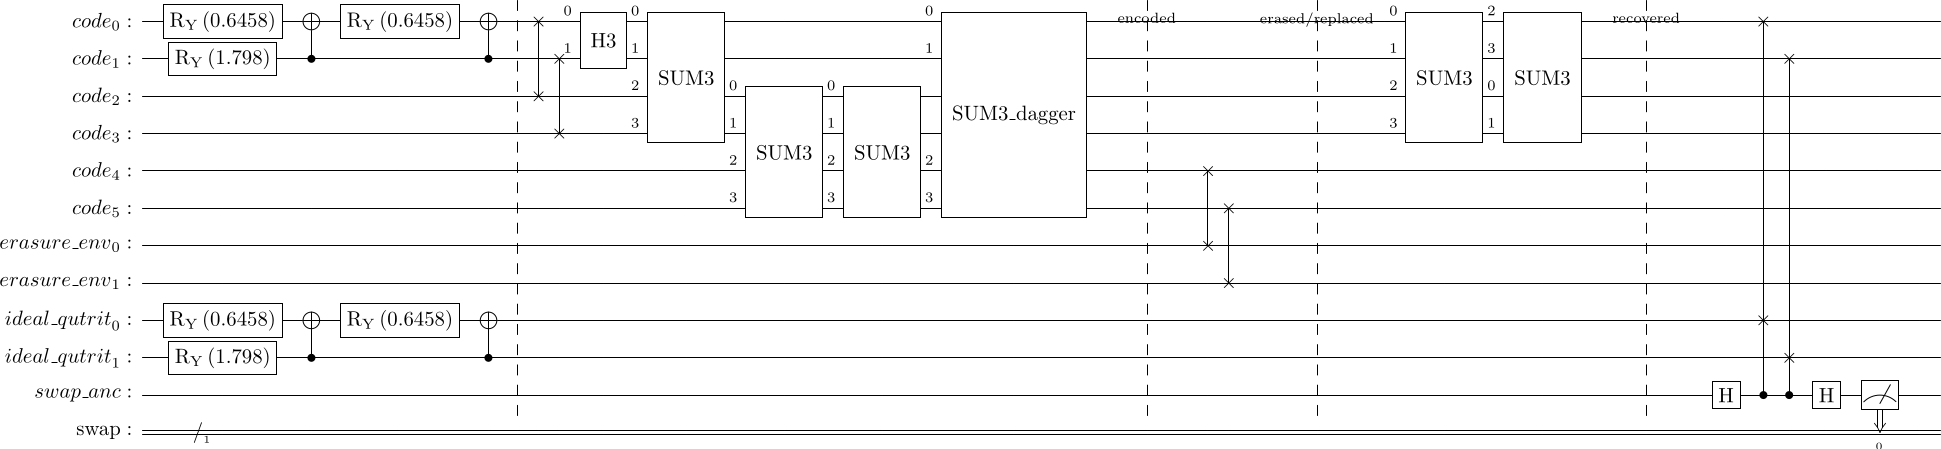

In [6]:
def build_qutrit_overlap_circuit(erased_share=ERASED_SHARE, theta1=THETA1, theta2=THETA2):
    if erased_share not in (1, 2, 3):
        raise ValueError("ERASED_SHARE must be 1, 2, or 3")

    code_q = QuantumRegister(6, "code")
    fresh = QuantumRegister(2, "erasure_env")
    ideal = QuantumRegister(2, "ideal_qutrit")
    swap_anc = QuantumRegister(1, "swap_anc")
    metric = ClassicalRegister(1, "swap")
    qc = QuantumCircuit(code_q, fresh, ideal, swap_anc, metric)

    shares = tuple((code_q[a], code_q[b]) for a, b in SHARE_PAIRS)
    prepare_real_qutrit(qc, shares[0], theta1, theta2)
    prepare_real_qutrit(qc, (ideal[0], ideal[1]), theta1, theta2)
    qc.barrier()

    append_qutrit_encoder(qc, shares)
    qc.barrier(label="encoded")

    lost_pair = shares[erased_share - 1]
    qc.swap(fresh[0], lost_pair[0])
    qc.swap(fresh[1], lost_pair[1])
    qc.barrier(label="erased/replaced")

    recovered_pair = append_qutrit_recovery(qc, erased_share, shares)
    qc.barrier(label="recovered")

    qc.h(swap_anc[0])
    qc.cswap(swap_anc[0], recovered_pair[0], ideal[0])
    qc.cswap(swap_anc[0], recovered_pair[1], ideal[1])
    qc.h(swap_anc[0])
    qc.measure(swap_anc[0], metric[0])
    return qc, metric, recovered_pair


qc, metric, recovered_pair = build_qutrit_overlap_circuit()
display(qc.draw(output='latex'))

In [7]:
compiled, counts = run_counts(qc, shots=SHOTS, optimization_level=OPTIMIZATION_LEVEL)
raw_metric = selected_raw_marginal(counts, qc, [metric[0]])
p0_raw = probability_zero_from_distribution(raw_metric)
overlap_raw = np.clip(2 * p0_raw - 1, 0.0, 1.0)

print("Backend:", BACKEND_LABEL)
print("Raw SWAP-test pass probability:", p0_raw)
print("Raw Embedded qutrit state overlap/fidelity:", overlap_raw)
print("Raw metric counts:", raw_metric)

if USE_M3:
    _, quasi, m3_probs, mapping = m3_mitigated_marginal(
        compiled, counts, qc, [metric[0]]
    )
    p0_m3 = probability_zero_from_distribution(m3_probs)
    overlap_m3 = np.clip(2 * p0_m3 - 1, 0.0, 1.0)
    print("M3 physical-qubit mapping:", mapping)
    print("M3 SWAP-test pass probability:", p0_m3)
    print("M3 Embedded qutrit state overlap/fidelity:", overlap_m3)
    print("M3 nearest probability distribution:", m3_probs)

print("Circuit depth (logical / transpiled):", qc.depth(), "/", compiled.depth())


Backend: ideal AerSimulator
Raw SWAP-test pass probability: 1.0
Raw Embedded qutrit state overlap/fidelity: 1.0
Raw metric counts: {'0': 20000}
M3 physical-qubit mapping: {0: 10}
M3 SWAP-test pass probability: 1.0
M3 Embedded qutrit state overlap/fidelity: 1.0
M3 nearest probability distribution: {'0': np.float32(1.0)}
Circuit depth (logical / transpiled): 18 / 21


### Noisy backend + M3 notes

`fake_brisbane` and `fake_torino` are the two noisy fake-backend choices used for comparisons. The circuit is transpiled to the selected fake device snapshot and executed locally with Aer noise copied from that snapshot. M3 is calibrated on the **physical qubits that hold the final measured metric bits after transpilation**, obtained from `mthree.utils.final_measurement_mapping`. The returned quasi-probabilities are converted to the nearest probability distribution before the SWAP-test probability is calculated.

For the qubit MCM decoders, readout mitigation only changes the ensemble statistics reported at the end. It cannot undo a wrong syndrome measurement that already caused a conditional correction during that shot.
